In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error,r2_score
from sklearn.preprocessing import MinMaxScaler

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
def LoadData_Explore(filename):
    df = None
    try:
        df = pd.read_csv(filename)
        print("Data loaded into dataframe successfully!!")
        print("Please find the shape of the data as follows:")
        display(df.shape)
        print("Please find the first 5 rows of data as follows:")
        display(df.head())
        print("Please find the last 5 rows of data as follows:")
        display(df.tail())
        print("Please find the information on the data and data type as follows:")
        display(df.info())
        print("Please find the descriptive stats for numeric columns as follows:")
        display(df.describe())
        #print("Please find the descriptive stats for non numeric columns as follows:")
        #display(df.describe(include='O'))
        print("Lets check the data types for all the columns in data:")
        display(df.dtypes)    
    except FileNotFoundError:
        print(f"Error: {filename} not found!")
    return df 

In [4]:
#Load data from csv file
df = LoadData_Explore('EmployeeProductivity.csv')


Data loaded into dataframe successfully!!
Please find the shape of the data as follows:


(10, 5)

Please find the first 5 rows of data as follows:


,Experience (yrs),Training Hours,Working Hours,Projects,Productivity Score
0,2,40,38,3,62
1,5,60,42,6,78
2,1,20,35,2,55
3,8,80,45,8,88
4,4,50,40,5,72


Please find the last 5 rows of data as follows:


,Experience (yrs),Training Hours,Working Hours,Projects,Productivity Score
5,10,90,48,9,92
6,3,30,37,4,65
7,6,70,44,7,82
8,7,75,46,7,85
9,2,25,36,3,60


Please find the information on the data and data type as follows:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Experience (yrs)     10 non-null     int64
 1   Training Hours       10 non-null     int64
 2   Working Hours        10 non-null     int64
 3   Projects             10 non-null     int64
 4   Productivity Score   10 non-null     int64
dtypes: int64(5)
memory usage: 532.0 bytes


None

Please find the descriptive stats for numeric columns as follows:


,Experience (yrs),Training Hours,Working Hours,Projects,Productivity Score
count,10.000000,10.000000,10.000000,10.000000,10.000000
mean,4.800000,54.000000,41.100000,5.400000,73.900000
std,2.936362,24.698178,4.557046,2.366432,12.939603
min,1.000000,20.000000,35.000000,2.000000,55.000000
25%,2.250000,32.500000,37.250000,3.250000,62.750000
50%,4.500000,55.000000,41.000000,5.500000,75.000000
75%,6.750000,73.750000,44.750000,7.000000,84.250000
max,10.000000,90.000000,48.000000,9.000000,92.000000


Lets check the data types for all the columns in data:


Experience (yrs)       int64
Training Hours         int64
Working Hours          int64
Projects               int64
Productivity Score     int64
dtype: object

In [5]:
#Check for nulls
df.isna().any().any()

np.False_

In [6]:
#Check for data duplicates
df.duplicated().any()

np.False_

Data is not having any Nulls or Duplicates!!

In [7]:
#Lets explore data 
df.head()

,Experience (yrs),Training Hours,Working Hours,Projects,Productivity Score
0,2,40,38,3,62
1,5,60,42,6,78
2,1,20,35,2,55
3,8,80,45,8,88
4,4,50,40,5,72


Observations: Here can see Experince is in years while the training & working hours are in hours. Lets do some Feature Engieering.


In [8]:
#Lets convert Experince into hours
df['Exp_in_Hours'] =  df['Experience (yrs)'] * 8760

In [9]:
df.head()

,Experience (yrs),Training Hours,Working Hours,Projects,Productivity Score,Exp_in_Hours
0,2,40,38,3,62,17520
1,5,60,42,6,78,43800
2,1,20,35,2,55,8760
3,8,80,45,8,88,70080
4,4,50,40,5,72,35040


In [10]:
#Lets remove the Experince (Yrs) cplumn as it is not required
df.drop('Experience (yrs)', axis=1, inplace= True)

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Training Hours       10 non-null     int64
 1   Working Hours        10 non-null     int64
 2   Projects             10 non-null     int64
 3   Productivity Score   10 non-null     int64
 4   Exp_in_Hours         10 non-null     int64
dtypes: int64(5)
memory usage: 532.0 bytes


In [12]:
#Lets create correleation matrix to understand the correlation between the features
corr_matrix = df.corr()
print(corr_matrix)

                     Training Hours  Working Hours  Projects  \
Training Hours             1.000000       0.993132  0.977151   
Working Hours              0.993132       1.000000  0.974701   
Projects                   0.977151       0.974701  1.000000   
Productivity Score         0.987045       0.985684  0.995696   
Exp_in_Hours               0.969810       0.973178  0.988194   

                     Productivity Score   Exp_in_Hours  
Training Hours                  0.987045      0.969810  
Working Hours                   0.985684      0.973178  
Projects                        0.995696      0.988194  
Productivity Score              1.000000      0.981991  
Exp_in_Hours                    0.981991      1.000000  


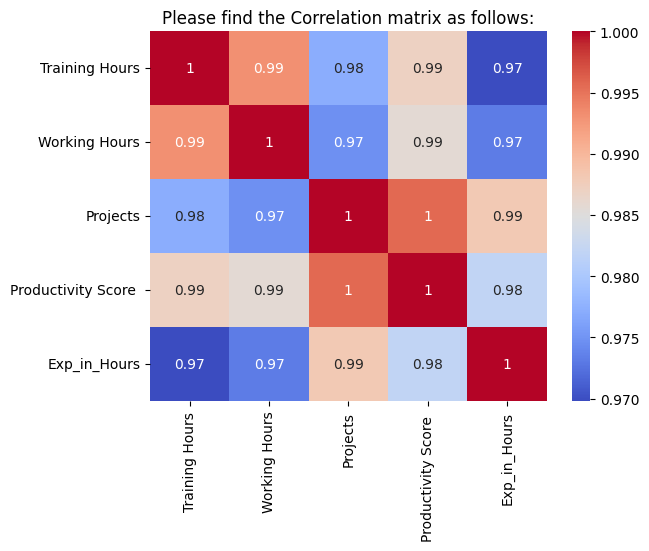

In [13]:
#Lets view the same in Seaborn Heatmap
sns.heatmap(corr_matrix, annot= True, cmap='coolwarm')
plt.title("Please find the Correlation matrix as follows:")
plt.show()

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Training Hours       10 non-null     int64
 1   Working Hours        10 non-null     int64
 2   Projects             10 non-null     int64
 3   Productivity Score   10 non-null     int64
 4   Exp_in_Hours         10 non-null     int64
dtypes: int64(5)
memory usage: 532.0 bytes


In [15]:
df['Productivity Score '].head()

0    62
1    78
2    55
3    88
4    72
Name: Productivity Score , dtype: int64

In [16]:
#As the Experince in Hours is on different scale compared to other features Normalization is required here.
#First lets split the train & test data before applying MinMaxScaler
y = df['Productivity Score ']
x = df.drop('Productivity Score ', axis=1)

In [17]:
x

,Training Hours,Working Hours,Projects,Exp_in_Hours
0,40,38,3,17520
1,60,42,6,43800
2,20,35,2,8760
3,80,45,8,70080
4,50,40,5,35040
5,90,48,9,87600
6,30,37,4,26280
7,70,44,7,52560
8,75,46,7,61320
9,25,36,3,17520


In [18]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [19]:
scaler = MinMaxScaler()
x_train = scaler.fit_transform(x_train)
x_test= scaler.fit_transform(x_test)

In [20]:
#Lets define the Linear Regression Model
lin_reg = LinearRegression()
lin_reg.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
y_train_pred = lin_reg.predict(x_train)
y_test_pred = lin_reg.predict(x_test)

In [22]:
#Lets run some metrics : MSE & R2 Score
mse_train = mean_squared_error(y_train, y_train_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
r2_train = r2_score(y_train, y_train_pred)
r2_test = r2_score(y_test, y_test_pred)

print("Training Set MSE:", mse_train)
print("Testing set MSE:", mse_test)
print("Training Data R2 Score:", r2_train)
print("Testing Data R2 Score:", r2_test)

Training Set MSE: 0.014251781472683883
Testing set MSE: 285.4434188477839
Training Data R2 Score: 0.9999147875547224
Testing Data R2 Score: -22.30150357941093


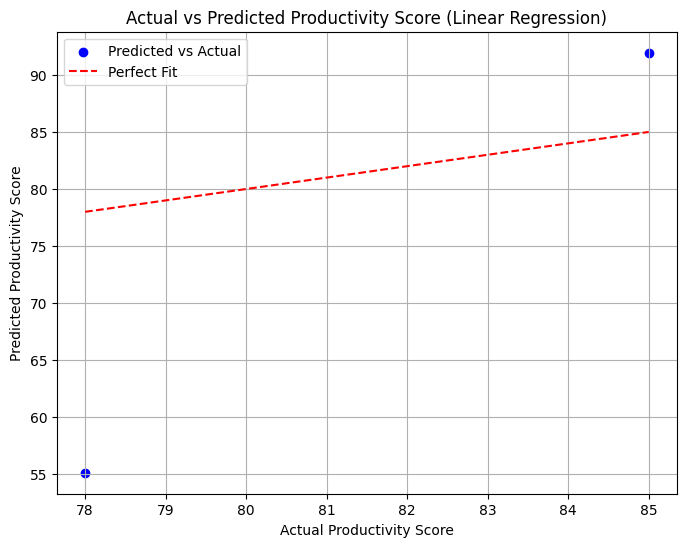

In [23]:
# Predict on test data
y_pred = lin_reg.predict(x_test)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', label='Perfect Fit')

plt.xlabel("Actual Productivity Score")
plt.ylabel("Predicted Productivity Score")
plt.title("Actual vs Predicted Productivity Score (Linear Regression)")
plt.legend()
plt.grid(True)
plt.show()

OBSERVATIOn:Above graph represents that the predicted scores are not so close to the prefect prediction. This model need more training and tunning in order to reduce its error.

In [24]:
#Lets predict on new data point
def predict_productivity(exp_years, training, working, projects):
    
    # Convert years → hours
    exp_hours = exp_years * 8760
    
    # Prepare input
    new_data = [[ training, working, projects,exp_hours]]
    
    # Scale using SAME scaler
    new_scaled = scaler.transform(new_data)
    
    # Predict
    return lin_reg.predict(new_scaled)[0]

# Example prediction
score = predict_productivity(5, 65, 41, 6)
print("Predicted Productivity Score:", score)

Predicted Productivity Score: 65.02830562153599


In [25]:
# Save model
import pickle
with open("model.pkl", "wb") as f:
    pickle.dump(lin_reg, f)

# Save scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Model and scaler saved!")

Model and scaler saved!


Interpretations: 

Which factor most strongly impacts productivity? 
As per the correlation matrix both training as well as working hours have positive correlation with Productivity Score. 

How does training affect productivity? 
Training hours has positive correlation with productivity score which means if training hours increases productivity scores also increases.

Should the company increase training hours or working hours?
As per the data both Working hours & Training Hours has strong/tight correlation with the Productivity Score.
Company shouldn't increase the working hours unless there is a proof that employees are underutlized.

What happens if Working Hours increase beyond optimal limits?
Increasing working hours beyond optimal limits may decrease productivity. Over working may exhaust employees and can lead to mistakes/errors. over working can lead to Burn out and will drop the creative & problem solving capabilities.
Over all productivity/her/day will decline.

Can productivity ever decrease with more experience? 
As per the provided data set(high collinear) productivity also has positive correlation with experience. Which mean as experience increases productivity also increases. This model cannot isolate the true effects of experince.

How would you detect overfitting in this model?
The training MSE & R2 score are higher/good while the testing MSE & R2 score are very poor. Which indicates model is overfit for the training data. This can be solved by increasing the training data added more features like Project Complexity Score, Task Complexity Score, Skill Levels..etc.

Suggest one new feature to improve prediction accuracy.
As data here is very less if we can increase the data it can improve the prediction accuracy. May be we can add few more features like Project Complexity Score, Task Complexity Score, Skill Levels..etc which can 